# AutoGluon Old Runs Result Report

This notebook summarizes previous AutoGluon experiments on the `relaxed dataset`. It is a **report-only notebook** and does not train new models.

Goals:

1. Combine old AutoGluon runs for `S2 only`, `Context only`, and `S2 + Context`.
2. Summarize metrics for regression targets: `DO`, `BOD`, `Turbidity`, `SS`, `TCB`, and `FCB`.
3. Summarize the existing NH3 classification results. NH3 regression is not included in this notebook.
4. Plot observed vs predicted, metric comparisons, residual diagnostics, and feature importance.
5. Export tables and figures that can be used for reporting to the advisor.
6. Document the recommended setup for the next final best-model training notebook.

Interpretation guardrails:

- `Turbidity` and `SS` are optical or near-direct water-quality targets and are the strongest Sentinel-2 candidates.
- `DO`, `BOD`, `TCB`, `FCB`, and `NH3` are non-optical or indirect proxy/risk targets. Do not claim that Sentinel-2 measures these directly.
- Regression results for non-optical targets should be interpreted as proxy estimation or screening evidence.


In [1]:

from pathlib import Path
from datetime import datetime
import json
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)

PROJECT_ROOT = Path(r"E:\Water Quality Research")
EXPERIMENT_ROOT = PROJECT_ROOT / "Experiments" / "autogluon_tabular"
RUN_ROOT = EXPERIMENT_ROOT / "runs"

# Existing completed AutoGluon runs. These are report-only inputs; this notebook does not train new models.
RUNS = {
    "S2 + Context": RUN_ROOT / "ag_relaxed_main_best_s2_context_best_quality_20260711_185242",
    "S2/Context diagnostic": RUN_ROOT / "ag_relaxed_diagnostic_s2_context_only_best_quality_20260711_231732",
}

REPORT_TAG = "relaxed_autogluon_old_runs_report"
REPORT_DIR = EXPERIMENT_ROOT / "reports" / REPORT_TAG
DIRS = {
    "root": REPORT_DIR,
    "tables": REPORT_DIR / "tables",
    "plots": REPORT_DIR / "plots",
    "summaries": REPORT_DIR / "summaries",
}
for d in DIRS.values():
    d.mkdir(parents=True, exist_ok=True)

print("Report directory:", REPORT_DIR)
for label, run_dir in RUNS.items():
    print(f"{label:24s}", run_dir, "exists=", run_dir.exists())

def df_to_markdown_table(df: pd.DataFrame, float_digits: int = 4) -> str:
    """Small dependency-free markdown table writer for report summaries."""
    if df.empty:
        return "_No rows_"
    out = df.copy()
    for col in out.columns:
        if pd.api.types.is_float_dtype(out[col]):
            out[col] = out[col].map(lambda x: "" if pd.isna(x) else f"{x:.{float_digits}g}")
        else:
            out[col] = out[col].map(lambda x: "" if pd.isna(x) else str(x))
    headers = [str(c) for c in out.columns]
    lines = ["| " + " | ".join(headers) + " |", "| " + " | ".join(["---"] * len(headers)) + " |"]
    for _, row in out.iterrows():
        vals = [str(row[c]).replace("\n", " ") for c in out.columns]
        lines.append("| " + " | ".join(vals) + " |")
    return "\n".join(lines)


Report directory: E:\Water Quality Research\Experiments\autogluon_tabular\reports\relaxed_autogluon_old_runs_report
S2 + Context             E:\Water Quality Research\Experiments\autogluon_tabular\runs\ag_relaxed_main_best_s2_context_best_quality_20260711_185242 exists= True
S2/Context diagnostic    E:\Water Quality Research\Experiments\autogluon_tabular\runs\ag_relaxed_diagnostic_s2_context_only_best_quality_20260711_231732 exists= True


## 1. Load Old AutoGluon Outputs

Read `metrics`, `predictions`, `leaderboards`, and `feature_importance` files from previous AutoGluon runs, then combine them into report tables.


In [2]:

def read_csv_if_exists(path: Path, source_run: str | None = None) -> pd.DataFrame:
    if not path.exists():
        print("MISSING:", path)
        return pd.DataFrame()
    df = pd.read_csv(path)
    if source_run is not None:
        df["source_run"] = source_run
    df["source_path"] = str(path)
    return df

reg_metric_frames = []
cls_metric_frames = []
reg_pred_frames = []
cls_pred_frames = []

for run_label, run_dir in RUNS.items():
    reg_metric_frames.append(read_csv_if_exists(run_dir / "metrics" / "metrics_regression_all.csv", run_label))
    cls_metric_frames.append(read_csv_if_exists(run_dir / "metrics" / "metrics_classification_all.csv", run_label))
    reg_pred_frames.append(read_csv_if_exists(run_dir / "predictions" / "predictions_regression_all.csv", run_label))
    cls_pred_frames.append(read_csv_if_exists(run_dir / "predictions" / "predictions_classification_all.csv", run_label))

reg_metrics_raw = pd.concat([x for x in reg_metric_frames if not x.empty], ignore_index=True)
cls_metrics_raw = pd.concat([x for x in cls_metric_frames if not x.empty], ignore_index=True)
reg_preds_raw = pd.concat([x for x in reg_pred_frames if not x.empty], ignore_index=True)
cls_preds_raw = pd.concat([x for x in cls_pred_frames if not x.empty], ignore_index=True)

print("Raw regression metrics:", reg_metrics_raw.shape)
print("Raw classification metrics:", cls_metrics_raw.shape)
print("Raw regression predictions:", reg_preds_raw.shape)
print("Raw classification predictions:", cls_preds_raw.shape)


Raw regression metrics: (24, 29)
Raw classification metrics: (4, 17)
Raw regression predictions: (2736, 16)
Raw classification predictions: (456, 16)


## 2. De-duplicate And Save Combined Tables

Some previous run outputs contain duplicate rows because cells may have been executed more than once. This section removes duplicates using keys based on target, feature set, model, transform, train/test size, and main metrics.


In [3]:

def dedupe_metrics(df: pd.DataFrame, task: str) -> pd.DataFrame:
    if df.empty:
        return df.copy()
    df = df.copy()
    if task == "regression":
        subset = [
            "target", "feature_set", "best_model", "transform", "n_features", "n_train", "n_test",
            "original_mae", "original_rmse", "original_r2", "original_pearson_r", "original_spearman_r", "original_bias",
        ]
    else:
        subset = [
            "target", "feature_set", "best_model", "n_features", "n_train", "n_test",
            "accuracy", "balanced_accuracy", "macro_f1",
        ]
    subset = [c for c in subset if c in df.columns]
    return df.drop_duplicates(subset=subset).reset_index(drop=True)


def dedupe_predictions(df: pd.DataFrame, task: str) -> pd.DataFrame:
    if df.empty:
        return df.copy()
    df = df.copy()
    if task == "regression":
        subset = ["sample_id", "target", "feature_set", "best_model", "y_true_original", "y_pred_original"]
    else:
        subset = ["sample_id", "target", "feature_set", "best_model", "y_true_label", "y_pred_label"]
    subset = [c for c in subset if c in df.columns]
    return df.drop_duplicates(subset=subset).reset_index(drop=True)

reg_metrics = dedupe_metrics(reg_metrics_raw, "regression")
cls_metrics = dedupe_metrics(cls_metrics_raw, "classification")
reg_preds = dedupe_predictions(reg_preds_raw, "regression")
cls_preds = dedupe_predictions(cls_preds_raw, "classification")

reg_metrics.to_csv(DIRS["tables"] / "autogluon_regression_metrics_all_feature_sets.csv", index=False, encoding="utf-8-sig")
cls_metrics.to_csv(DIRS["tables"] / "autogluon_classification_metrics_all_feature_sets.csv", index=False, encoding="utf-8-sig")
reg_preds.to_csv(DIRS["tables"] / "autogluon_regression_predictions_all_feature_sets.csv", index=False, encoding="utf-8-sig")
cls_preds.to_csv(DIRS["tables"] / "autogluon_classification_predictions_all_feature_sets.csv", index=False, encoding="utf-8-sig")

print("Clean regression metrics:", reg_metrics.shape)
print("Clean classification metrics:", cls_metrics.shape)
print("Clean regression predictions:", reg_preds.shape)
print("Clean classification predictions:", cls_preds.shape)

display(reg_metrics[[
    "target", "feature_set", "best_model", "n_features", "n_train", "n_test", "transform",
    "original_mae", "original_rmse", "original_r2", "original_pearson_r", "original_spearman_r", "original_bias",
]].sort_values(["target", "feature_set"]))


Clean regression metrics: (18, 29)
Clean classification metrics: (3, 17)
Clean regression predictions: (2053, 16)
Clean classification predictions: (342, 16)


,target,feature_set,best_model,n_features,n_train,n_test,transform,original_mae,original_rmse,original_r2,original_pearson_r,original_spearman_r,original_bias
6,BOD,Context only,WeightedEnsemble_L2,107,276,114,raw,0.537530,0.800352,0.135610,0.446174,0.449944,-0.216462
0,BOD,S2 + Context,WeightedEnsemble_L2,139,276,114,raw,0.517185,0.758006,0.224660,0.498461,0.493516,-0.120442
7,BOD,S2 only,WeightedEnsemble_L3,32,276,114,raw,0.506679,0.725601,0.289534,0.548461,0.517062,-0.069912
8,DO,Context only,WeightedEnsemble_L3,107,276,114,raw,0.787353,0.974571,0.304142,0.634030,0.549316,-0.239409
1,DO,S2 + Context,WeightedEnsemble_L3,139,276,114,raw,0.723324,0.892807,0.416004,0.672975,0.595425,-0.179017
9,DO,S2 only,WeightedEnsemble_L3,32,276,114,raw,0.875674,1.108598,0.099585,0.425214,0.345515,-0.123493
10,FCB,Context only,WeightedEnsemble_L3,107,276,114,log1p,1379.452930,3115.216125,0.029497,0.422332,0.511254,-1027.854030
2,FCB,S2 + Context,WeightedEnsemble_L2,139,276,114,log1p,1386.331619,3121.710680,0.025446,0.465854,0.554678,-1097.281100
11,FCB,S2 only,WeightedEnsemble_L2,32,276,114,log1p,1509.351306,3254.325543,-0.059113,0.319500,0.347542,-1163.145968
12,SS,Context only,WeightedEnsemble_L2,107,276,114,log1p,18.950128,59.380710,0.052272,0.278748,0.662837,-9.501883


## 3. Regression Metric Summary

This section uses `original_*` metrics as the main reporting metrics because they are in the original water-quality units.

For targets transformed with `log1p`, also inspect `modelscale_*` metrics to understand performance on the log/rank scale.


In [4]:

metric_cols = [
    "original_mae", "original_rmse", "original_r2", "original_pearson_r", "original_spearman_r", "original_bias",
    "modelscale_rmse", "modelscale_r2", "modelscale_pearson_r", "modelscale_spearman_r",
]
for col in metric_cols:
    if col in reg_metrics.columns:
        reg_metrics[col] = pd.to_numeric(reg_metrics[col], errors="coerce")

regression_summary = reg_metrics[[
    "target", "feature_set", "best_model", "n_features", "n_train", "n_test", "transform",
    "original_mae", "original_rmse", "original_r2", "original_pearson_r", "original_spearman_r", "original_bias",
    "modelscale_rmse", "modelscale_r2", "modelscale_pearson_r", "modelscale_spearman_r",
]].sort_values(["target", "original_rmse", "original_mae"]).reset_index(drop=True)

best_by_target = (
    regression_summary
    .sort_values(["target", "original_rmse", "original_mae"], ascending=[True, True, True])
    .groupby("target", as_index=False)
    .head(1)
    .reset_index(drop=True)
)

regression_summary.to_csv(DIRS["tables"] / "regression_summary_by_target_feature_set.csv", index=False, encoding="utf-8-sig")
best_by_target.to_csv(DIRS["tables"] / "regression_best_by_target_rmse.csv", index=False, encoding="utf-8-sig")

print("Best regression result by target, selected by lowest original RMSE")
display(best_by_target)


Best regression result by target, selected by lowest original RMSE


,target,feature_set,best_model,n_features,n_train,n_test,transform,original_mae,original_rmse,original_r2,original_pearson_r,original_spearman_r,original_bias,modelscale_rmse,modelscale_r2,modelscale_pearson_r,modelscale_spearman_r
0,BOD,S2 only,WeightedEnsemble_L3,32,276,114,raw,0.506679,0.725601,0.289534,0.548461,0.517062,-0.069912,0.725601,0.289534,0.548461,0.517062
1,DO,S2 + Context,WeightedEnsemble_L3,139,276,114,raw,0.723324,0.892807,0.416004,0.672975,0.595425,-0.179017,0.892807,0.416004,0.672975,0.595425
2,FCB,Context only,WeightedEnsemble_L3,107,276,114,log1p,1379.452930,3115.216125,0.029497,0.422332,0.511254,-1027.854030,1.720391,0.296511,0.558096,0.511254
3,SS,S2 + Context,WeightedEnsemble_L2,139,276,114,log1p,16.724097,56.691389,0.136172,0.402452,0.708907,-8.807900,0.621866,0.505070,0.716855,0.708907
4,TCB,Context only,WeightedEnsemble_L2,107,276,114,log1p,3965.049479,8246.388082,0.109357,0.448682,0.632319,-2442.018757,1.473982,0.378635,0.633714,0.632319
5,Turbidity,S2 + Context,WeightedEnsemble_L2,139,276,114,log1p,22.677512,53.617943,0.273683,0.572618,0.708827,-12.852840,0.766207,0.484110,0.724171,0.708827


In [5]:

# Pivot views for fast reading.
rmse_pivot = reg_metrics.pivot_table(index="target", columns="feature_set", values="original_rmse", aggfunc="min")
r2_pivot = reg_metrics.pivot_table(index="target", columns="feature_set", values="original_r2", aggfunc="max")
spearman_pivot = reg_metrics.pivot_table(index="target", columns="feature_set", values="original_spearman_r", aggfunc="max")

for name, df in [
    ("pivot_original_rmse_by_feature_set.csv", rmse_pivot),
    ("pivot_original_r2_by_feature_set.csv", r2_pivot),
    ("pivot_original_spearman_by_feature_set.csv", spearman_pivot),
]:
    df.to_csv(DIRS["tables"] / name, encoding="utf-8-sig")

print("RMSE pivot")
display(rmse_pivot)
print("R2 pivot")
display(r2_pivot)
print("Spearman pivot")
display(spearman_pivot)


RMSE pivot


feature_set,Context only,S2 + Context,S2 only
target,,,
BOD,0.800352,0.758006,0.725601
DO,0.974571,0.892807,1.108598
FCB,3115.216125,3121.710680,3254.325543
SS,59.380710,56.691389,59.908073
TCB,8246.388082,8362.328233,8606.735833
Turbidity,57.591714,53.617943,58.748376


R2 pivot


feature_set,Context only,S2 + Context,S2 only
target,,,
BOD,0.135610,0.224660,0.289534
DO,0.304142,0.416004,0.099585
FCB,0.029497,0.025446,-0.059113
SS,0.052272,0.136172,0.035363
TCB,0.109357,0.084137,0.029819
Turbidity,0.162035,0.273683,0.128038


Spearman pivot


feature_set,Context only,S2 + Context,S2 only
target,,,
BOD,0.449944,0.493516,0.517062
DO,0.549316,0.595425,0.345515
FCB,0.511254,0.554678,0.347542
SS,0.662837,0.708907,0.659721
TCB,0.632319,0.639738,0.414328
Turbidity,0.598527,0.708827,0.697830


## 4. Metric Comparison Plots

Compare feature sets by target to see whether `S2 only`, `Context only`, or `S2 + Context` performs best for each parameter.


Saved: E:\Water Quality Research\Experiments\autogluon_tabular\reports\relaxed_autogluon_old_runs_report\plots\metric_comparison_by_feature_set.png


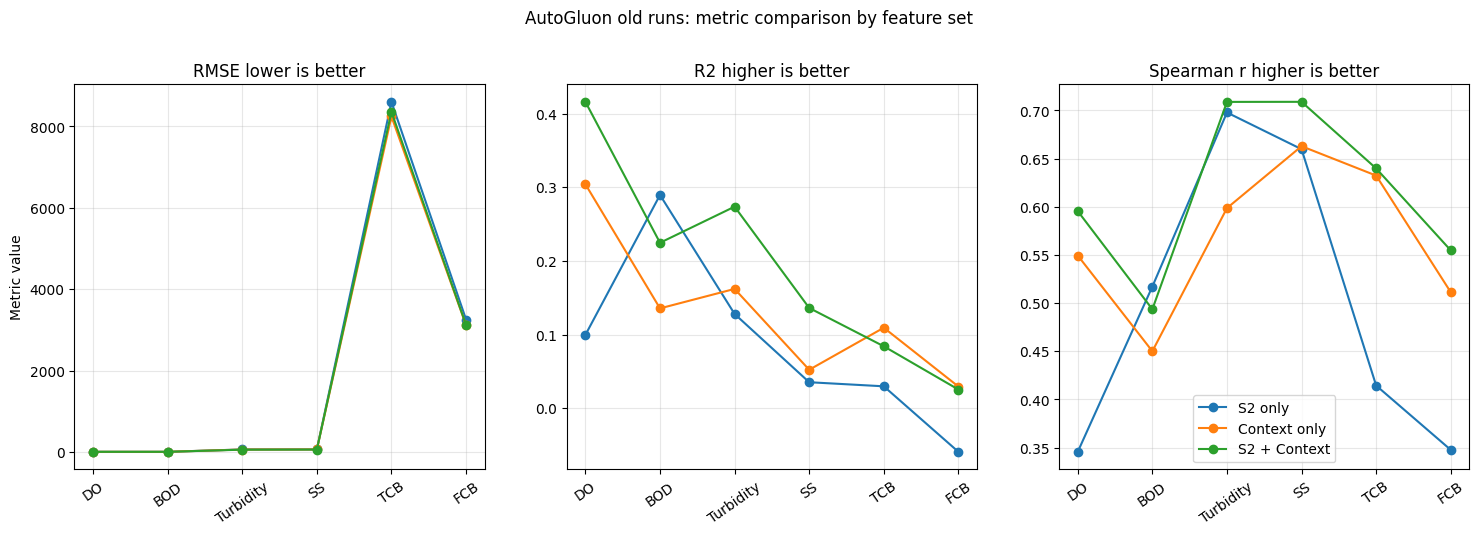

In [6]:

def save_current_fig(name: str):
    path = DIRS["plots"] / name
    plt.savefig(path, dpi=180, bbox_inches="tight")
    print("Saved:", path)

feature_order = ["S2 only", "Context only", "S2 + Context"]
target_order = ["DO", "BOD", "Turbidity", "SS", "TCB", "FCB"]
plot_df = reg_metrics.copy()
plot_df["feature_set"] = pd.Categorical(plot_df["feature_set"], categories=feature_order, ordered=True)
plot_df["target"] = pd.Categorical(plot_df["target"], categories=target_order, ordered=True)
plot_df = plot_df.sort_values(["target", "feature_set"])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics_to_plot = [
    ("original_rmse", "RMSE lower is better"),
    ("original_r2", "R2 higher is better"),
    ("original_spearman_r", "Spearman r higher is better"),
]
for ax, (metric, title) in zip(axes, metrics_to_plot):
    for fs in feature_order:
        sub = plot_df[plot_df["feature_set"] == fs]
        ax.plot(sub["target"].astype(str), sub[metric], marker="o", label=fs)
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis="x", rotation=35)
axes[0].set_ylabel("Metric value")
axes[-1].legend(loc="best")
plt.suptitle("AutoGluon old runs: metric comparison by feature set", y=1.03)
save_current_fig("metric_comparison_by_feature_set.png")
plt.show()


## 5. Observed vs Predicted Plots

These plots use the best result for each target selected by the lowest `original RMSE`.

The dashed line is the 1:1 line. Points closer to this line indicate predictions closer to observed values.


Saved: E:\Water Quality Research\Experiments\autogluon_tabular\reports\relaxed_autogluon_old_runs_report\plots\observed_vs_predicted_best_by_target.png


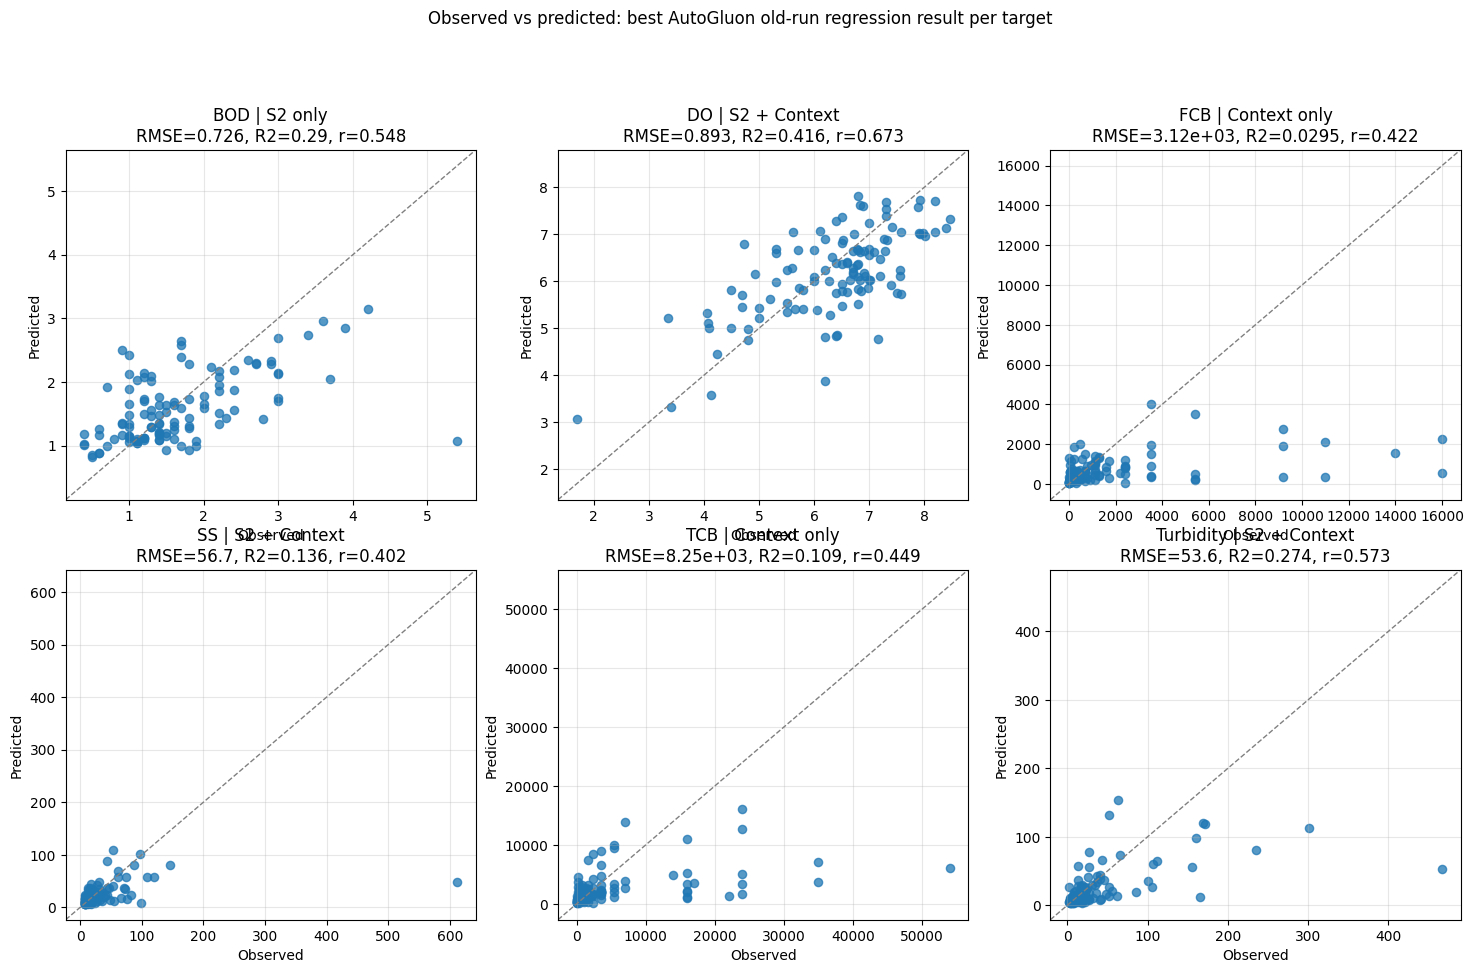

In [7]:

def finite_xy(df, x_col="y_true_original", y_col="y_pred_original"):
    out = df[[x_col, y_col]].copy()
    out[x_col] = pd.to_numeric(out[x_col], errors="coerce")
    out[y_col] = pd.to_numeric(out[y_col], errors="coerce")
    return out.dropna()

best_keys = best_by_target[["target", "feature_set", "best_model"]].copy()
best_pred_frames = []
for _, row in best_keys.iterrows():
    sub = reg_preds[
        (reg_preds["target"].astype(str) == str(row["target"])) &
        (reg_preds["feature_set"].astype(str) == str(row["feature_set"]))
    ].copy()
    best_pred_frames.append(sub)

best_preds = pd.concat(best_pred_frames, ignore_index=True) if best_pred_frames else pd.DataFrame()
best_preds.to_csv(DIRS["tables"] / "regression_predictions_best_by_target_rmse.csv", index=False, encoding="utf-8-sig")

n_targets = best_by_target.shape[0]
cols = 3
rows = math.ceil(n_targets / cols)
fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 5 * rows))
axes = np.array(axes).reshape(-1)

for ax, (_, row) in zip(axes, best_by_target.iterrows()):
    target = row["target"]
    feature_set = row["feature_set"]
    sub = best_preds[(best_preds["target"] == target) & (best_preds["feature_set"] == feature_set)].copy()
    xy = finite_xy(sub)
    ax.scatter(xy["y_true_original"], xy["y_pred_original"], alpha=0.75, s=35)
    if not xy.empty:
        lo = np.nanmin([xy["y_true_original"].min(), xy["y_pred_original"].min()])
        hi = np.nanmax([xy["y_true_original"].max(), xy["y_pred_original"].max()])
        pad = (hi - lo) * 0.05 if hi > lo else 1
        ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], "--", color="gray", linewidth=1)
        ax.set_xlim(lo - pad, hi + pad)
        ax.set_ylim(lo - pad, hi + pad)
    ax.set_title(
        f"{target} | {feature_set}\n"
        f"RMSE={row['original_rmse']:.3g}, R2={row['original_r2']:.3g}, r={row['original_pearson_r']:.3g}"
    )
    ax.set_xlabel("Observed")
    ax.set_ylabel("Predicted")
    ax.grid(True, alpha=0.3)

for ax in axes[n_targets:]:
    ax.axis("off")

plt.suptitle("Observed vs predicted: best AutoGluon old-run regression result per target", y=1.02)
save_current_fig("observed_vs_predicted_best_by_target.png")
plt.show()


## 6. Residual Diagnostics

Inspect residuals from the best model for each target to check bias, year effects, and large outliers.


Saved: E:\Water Quality Research\Experiments\autogluon_tabular\reports\relaxed_autogluon_old_runs_report\plots\residual_diagnostics_best_by_target.png


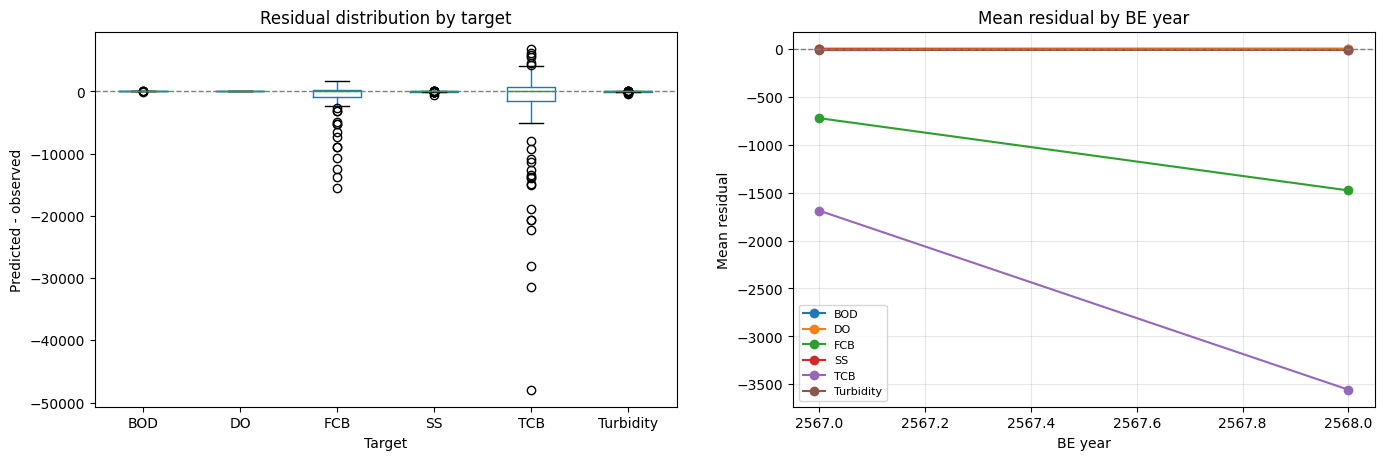

In [8]:

if not best_preds.empty:
    best_preds["residual_original"] = pd.to_numeric(best_preds["residual_original"], errors="coerce")
    best_preds["year_be"] = pd.to_numeric(best_preds["year_be"], errors="coerce")

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    best_preds.boxplot(column="residual_original", by="target", ax=axes[0], grid=False)
    axes[0].axhline(0, color="gray", linestyle="--", linewidth=1)
    axes[0].set_title("Residual distribution by target")
    axes[0].set_xlabel("Target")
    axes[0].set_ylabel("Predicted - observed")

    for target, sub in best_preds.groupby("target"):
        yearly = sub.groupby("year_be", as_index=False)["residual_original"].mean()
        axes[1].plot(yearly["year_be"], yearly["residual_original"], marker="o", label=target)
    axes[1].axhline(0, color="gray", linestyle="--", linewidth=1)
    axes[1].set_title("Mean residual by BE year")
    axes[1].set_xlabel("BE year")
    axes[1].set_ylabel("Mean residual")
    axes[1].grid(True, alpha=0.3)
    axes[1].legend(loc="best", fontsize=8)

    plt.suptitle("")
    save_current_fig("residual_diagnostics_best_by_target.png")
    plt.show()


## 7. NH3 Classification Summary

NH3 regression is not trained in this notebook. This section summarizes only the existing NH3 classification results from previous AutoGluon runs.


,target,feature_set,best_model,n_features,n_train,n_test,accuracy,balanced_accuracy,macro_f1
0,NH3,Context only,WeightedEnsemble_L2,107,276,114,0.307018,0.379978,0.250640
1,NH3,S2 + Context,WeightedEnsemble_L2,139,276,114,0.280702,0.354011,0.232980
2,NH3,S2 only,WeightedEnsemble_L2,32,276,114,0.280702,0.341517,0.227619


Saved: E:\Water Quality Research\Experiments\autogluon_tabular\reports\relaxed_autogluon_old_runs_report\plots\nh3_classification_metric_comparison.png


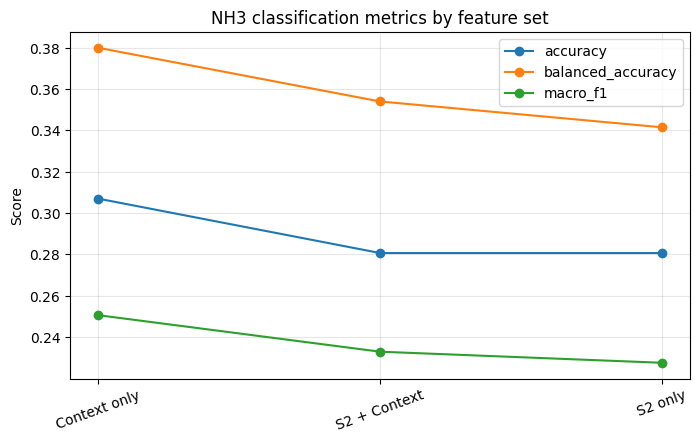

In [9]:

if not cls_metrics.empty:
    cls_metrics_clean = cls_metrics.sort_values(["macro_f1", "balanced_accuracy", "accuracy"], ascending=False).reset_index(drop=True)
    cls_metrics_clean.to_csv(DIRS["tables"] / "nh3_classification_summary.csv", index=False, encoding="utf-8-sig")
    display(cls_metrics_clean[[
        "target", "feature_set", "best_model", "n_features", "n_train", "n_test", "accuracy", "balanced_accuracy", "macro_f1"
    ]])

    fig, ax = plt.subplots(figsize=(8, 4.5))
    for metric in ["accuracy", "balanced_accuracy", "macro_f1"]:
        ax.plot(cls_metrics_clean["feature_set"], cls_metrics_clean[metric], marker="o", label=metric)
    ax.set_title("NH3 classification metrics by feature set")
    ax.set_ylabel("Score")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best")
    plt.xticks(rotation=20)
    save_current_fig("nh3_classification_metric_comparison.png")
    plt.show()
else:
    print("No classification metrics found.")


Saved: E:\Water Quality Research\Experiments\autogluon_tabular\reports\relaxed_autogluon_old_runs_report\plots\nh3_best_confusion_matrix.png


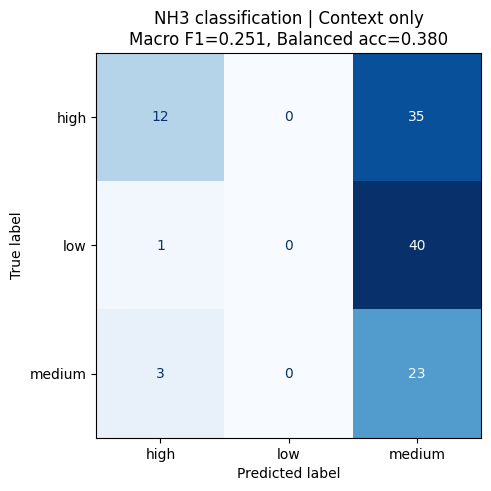

In [10]:

# Plot confusion matrix for the best NH3 classification result.
if not cls_metrics.empty and not cls_preds.empty:
    best_cls = cls_metrics.sort_values(["macro_f1", "balanced_accuracy", "accuracy"], ascending=False).iloc[0]
    sub = cls_preds[
        (cls_preds["target"].astype(str) == str(best_cls["target"])) &
        (cls_preds["feature_set"].astype(str) == str(best_cls["feature_set"]))
    ].copy()
    labels = sorted(set(sub["y_true_label"].dropna()) | set(sub["y_pred_label"].dropna()))
    cm = confusion_matrix(sub["y_true_label"], sub["y_pred_label"], labels=labels)
    cm_df = pd.DataFrame(cm, index=[f"true_{x}" for x in labels], columns=[f"pred_{x}" for x in labels])
    cm_df.to_csv(DIRS["tables"] / "nh3_best_confusion_matrix.csv", encoding="utf-8-sig")

    fig, ax = plt.subplots(figsize=(6, 5))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(ax=ax, values_format="d", cmap="Blues", colorbar=False)
    ax.set_title(
        f"NH3 classification | {best_cls['feature_set']}\n"
        f"Macro F1={best_cls['macro_f1']:.3f}, Balanced acc={best_cls['balanced_accuracy']:.3f}"
    )
    save_current_fig("nh3_best_confusion_matrix.png")
    plt.show()


## 8. Feature Importance Summary

Read feature importance files from previous AutoGluon runs and show the top features for the best feature set of each target.


In [11]:

def feature_set_to_slug(feature_set: str) -> str:
    return feature_set.replace(" + ", "_plus_").replace(" ", "_")

importance_frames = []
for _, row in best_by_target.iterrows():
    target = str(row["target"])
    feature_set = str(row["feature_set"])
    slug = feature_set_to_slug(feature_set)
    possible_paths = []
    for run_label, run_dir in RUNS.items():
        possible_paths.append(run_dir / "feature_importance" / f"feature_importance_{target}__{slug}.csv")
    found = [p for p in possible_paths if p.exists()]
    if not found:
        print("No feature importance found for", target, feature_set)
        continue
    fi = pd.read_csv(found[0])
    fi["target"] = target
    fi["feature_set"] = feature_set
    fi["source_path"] = str(found[0])
    importance_frames.append(fi)

feature_importance_best = pd.concat(importance_frames, ignore_index=True) if importance_frames else pd.DataFrame()
if not feature_importance_best.empty:
    feature_importance_best.to_csv(DIRS["tables"] / "feature_importance_best_by_target.csv", index=False, encoding="utf-8-sig")
    display(feature_importance_best.groupby(["target", "feature_set"]).head(10))
else:
    print("No feature importance files found.")


,Unnamed: 0,importance,stddev,p_value,n,p99_high,p99_low,target,feature_set,source_path
0,B7_B4_median,0.087594,0.023895,0.000603,5,0.136795,0.038394,BOD,S2 only,E:\Water Quality Research\Experiments\autogluo...
1,NDCI_median,0.055967,0.026799,0.004760,5,0.111146,0.000788,BOD,S2 only,E:\Water Quality Research\Experiments\autogluo...
2,secchi_formula_s2_script_median,0.027229,0.009145,0.001322,5,0.046059,0.008399,BOD,S2 only,E:\Water Quality Research\Experiments\autogluo...
3,AWEIsh_median,0.026820,0.018918,0.016928,5,0.065772,-0.012132,BOD,S2 only,E:\Water Quality Research\Experiments\autogluo...
4,B5_median,0.025427,0.012609,0.005374,5,0.051389,-0.000535,BOD,S2 only,E:\Water Quality Research\Experiments\autogluo...
5,Red_Blue_median,0.024114,0.006602,0.000612,5,0.037707,0.010520,BOD,S2 only,E:\Water Quality Research\Experiments\autogluo...
6,MNDWI_median,0.024087,0.014642,0.010617,5,0.054235,-0.006061,BOD,S2 only,E:\Water Quality Research\Experiments\autogluo...
7,salinity_formula_s2_script_median,0.022919,0.005128,0.000282,5,0.033477,0.012360,BOD,S2 only,E:\Water Quality Research\Experiments\autogluo...
8,B5_B4_median,0.020720,0.017641,0.029207,5,0.057043,-0.015604,BOD,S2 only,E:\Water Quality Research\Experiments\autogluo...
9,B1_median,0.019655,0.008584,0.003443,5,0.037329,0.001980,BOD,S2 only,E:\Water Quality Research\Experiments\autogluo...


Saved: E:\Water Quality Research\Experiments\autogluon_tabular\reports\relaxed_autogluon_old_runs_report\plots\feature_importance_top10_best_by_target.png


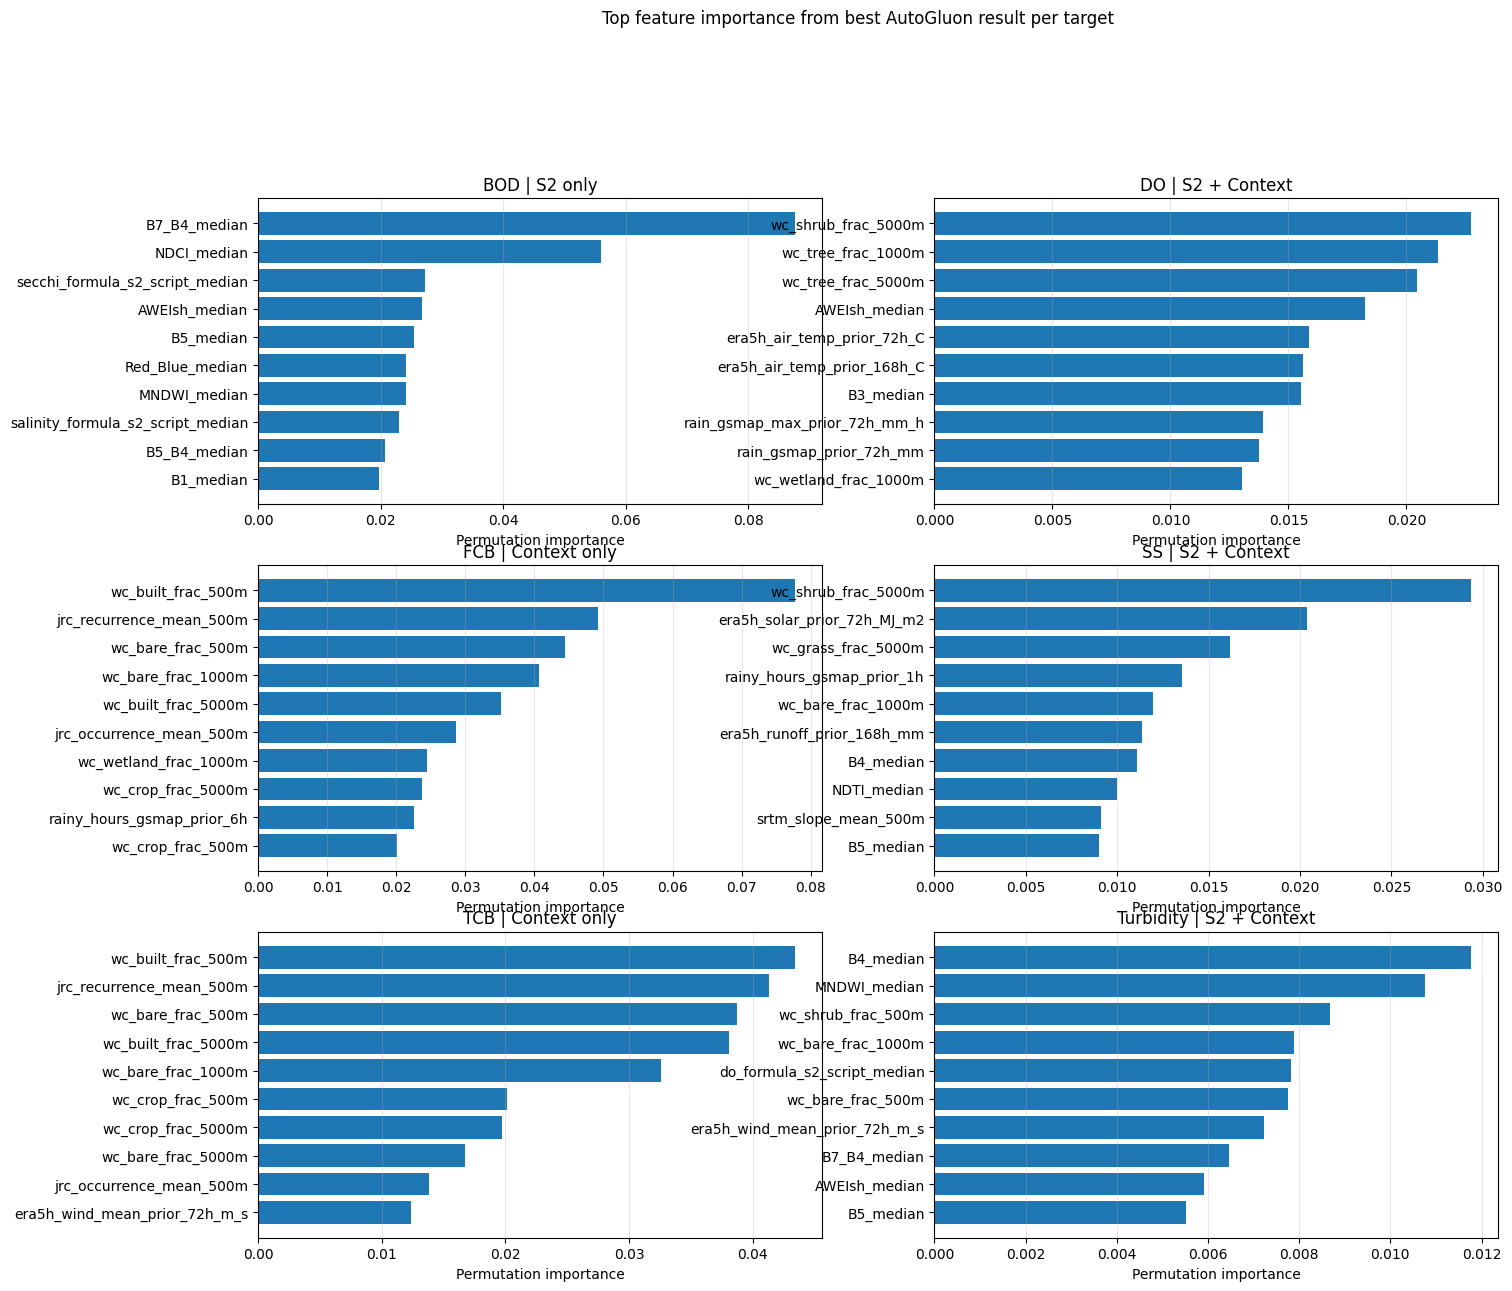

In [12]:

if not feature_importance_best.empty:
    top_n = 10
    targets = list(best_by_target["target"])
    cols = 2
    rows = math.ceil(len(targets) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(8 * cols, 4.5 * rows))
    axes = np.array(axes).reshape(-1)

    for ax, target in zip(axes, targets):
        sub = feature_importance_best[feature_importance_best["target"] == target].copy()
        if "importance" not in sub.columns:
            ax.axis("off")
            continue
        sub = sub.sort_values("importance", ascending=False).head(top_n).iloc[::-1]
        # AutoGluon stores feature name either as index column or feature column depending on version/export path.
        feature_col = "feature" if "feature" in sub.columns else sub.columns[0]
        ax.barh(sub[feature_col].astype(str), sub["importance"])
        fs = sub["feature_set"].iloc[0] if not sub.empty else ""
        ax.set_title(f"{target} | {fs}")
        ax.set_xlabel("Permutation importance")
        ax.grid(True, axis="x", alpha=0.3)

    for ax in axes[len(targets):]:
        ax.axis("off")

    plt.suptitle("Top feature importance from best AutoGluon result per target", y=1.02)
    save_current_fig("feature_importance_top10_best_by_target.png")
    plt.show()


## 9. Target-wise Interpretation Table

This table translates the model results into research interpretation: which targets remain suitable for regression and which targets should be treated as proxy/risk-screening targets.


In [13]:

def interpret_target(row: pd.Series) -> str:
    target = str(row["target"])
    r2 = row.get("original_r2", np.nan)
    spearman = row.get("original_spearman_r", np.nan)
    if target in ["Turbidity", "SS"]:
        if pd.notna(spearman) and spearman >= 0.6:
            return "Optical target with useful rank/log-scale signal; suitable for continued regression and high-event classification."
        return "Optical target but regression remains limited; inspect clouds/match window/outliers and consider high-event classification."
    if target == "DO":
        if pd.notna(r2) and r2 >= 0.3:
            return "Best non-optical proxy target; S2/context can support proxy estimation but not direct measurement."
        return "Non-optical proxy with limited predictive performance; use cautiously."
    if target == "BOD":
        return "Non-optical proxy target; some signal exists, but exact regression should be reported cautiously."
    if target in ["TCB", "FCB"]:
        return "Microbial/non-optical target; exact regression is weak. Consider risk classification for next phase."
    return "Interpret cautiously."

interpretation = best_by_target.copy()
interpretation["target_group"] = interpretation["target"].map({
    "Turbidity": "optical/near-direct",
    "SS": "optical/near-direct",
    "DO": "non-optical proxy",
    "BOD": "non-optical proxy",
    "TCB": "microbial proxy/risk",
    "FCB": "microbial proxy/risk",
})
interpretation["interpretation"] = interpretation.apply(interpret_target, axis=1)
interpretation = interpretation[[
    "target", "target_group", "feature_set", "best_model", "transform", "original_rmse", "original_r2",
    "original_pearson_r", "original_spearman_r", "original_bias", "interpretation"
]]
interpretation.to_csv(DIRS["tables"] / "target_wise_interpretation_best_regression.csv", index=False, encoding="utf-8-sig")
display(interpretation)


,target,target_group,feature_set,best_model,transform,original_rmse,original_r2,original_pearson_r,original_spearman_r,original_bias,interpretation
0,BOD,non-optical proxy,S2 only,WeightedEnsemble_L3,raw,0.725601,0.289534,0.548461,0.517062,-0.069912,"Non-optical proxy target; some signal exists, ..."
1,DO,non-optical proxy,S2 + Context,WeightedEnsemble_L3,raw,0.892807,0.416004,0.672975,0.595425,-0.179017,Best non-optical proxy target; S2/context can ...
2,FCB,microbial proxy/risk,Context only,WeightedEnsemble_L3,log1p,3115.216125,0.029497,0.422332,0.511254,-1027.854030,Microbial/non-optical target; exact regression...
3,SS,optical/near-direct,S2 + Context,WeightedEnsemble_L2,log1p,56.691389,0.136172,0.402452,0.708907,-8.807900,Optical target with useful rank/log-scale sign...
4,TCB,microbial proxy/risk,Context only,WeightedEnsemble_L2,log1p,8246.388082,0.109357,0.448682,0.632319,-2442.018757,Microbial/non-optical target; exact regression...
5,Turbidity,optical/near-direct,S2 + Context,WeightedEnsemble_L2,log1p,53.617943,0.273683,0.572618,0.708827,-12.852840,Optical target with useful rank/log-scale sign...


## 10. Final Best-model Training Setup Plan

After this old-run summary, the next `final best-model training` notebook should use a fixed, reproducible setup rather than another broad exploration.

### Purpose

Train final models for advisor reporting and thesis use, using model choices justified by the old-run evidence.

### Dataset

- Main dataset: `relaxed dataset`
- Test strategy for reported performance:
  - Train: BE 2562-2566
  - Test: BE 2567-2568
- Do not use the `strict` dataset as the main dataset in this round because it has fewer samples. It can be used later as a sensitivity or robustness check.
- Do not use the `full dataset` as the main metric dataset because image/QA conditions may be looser than the relaxed dataset.

### Targets

Use final regression for:

- `DO`, raw target
- `BOD`, raw target
- `Turbidity`, `log1p`
- `SS`, `log1p`
- `TCB`, `log1p`
- `FCB`, `log1p`

NH3 regression is **not included** in the current plan. Keep the existing NH3 classification results as separate evidence, or reformulate NH3 later.

### Feature Set Strategy

Use the results from this notebook in two ways:

1. **Unified setup for a simple system pipeline**
   - Use `S2 + Context` for all targets.
   - This is easier to explain and deploy.

2. **Target-specific best setup for best-effort performance**
   - Select the best feature set per target from `regression_best_by_target_rmse.csv`.
   - This is better for showing that the study has tested the strongest regression setup available from the old experiments.

Recommended reporting:

- Main comparison: all three feature sets from the old runs.
- Final best-effort: target-specific best feature set.

### Model Setup

- AutoGluon `TabularPredictor`
- Preset: `best_quality`
- Time limit: 1800-3600 seconds per target-feature setup
- Validation mode: internal validation using training years only
- Exclude `FASTAI` if the local environment remains unstable for that model family
- Model selection metric:
  - Regression: RMSE
  - Report additional metrics: MAE, R2, Pearson r, Spearman r, and Bias

### Outputs For The Final Training Notebook

- `final_model_registry.csv`: target, selected feature set, model path, best model, transform
- `final_test_metrics.csv`: metrics on the temporal test set
- `final_predictions_test.csv`: observed, predicted, and residual values for every target
- `final_observed_vs_predicted.png`
- `final_residual_diagnostics.png`
- `final_feature_importance.csv`
- `final_interpretation_summary.md`

### Important Reporting Statement

For non-optical targets such as `DO`, `BOD`, `TCB`, and `FCB`, report the results as **proxy estimation** or **screening evidence**, not as direct Sentinel-2 measurement.


In [14]:

# Write concise markdown summary for reporting.
summary_lines = [
    "# AutoGluon Old Runs Result Report",
    "",
    f"Generated: {datetime.now().isoformat(timespec='seconds')}",
    f"Report directory: `{REPORT_DIR}`",
    "",
    "## Inputs",
]
for label, run_dir in RUNS.items():
    summary_lines.append(f"- {label}: `{run_dir}`")

summary_lines.extend([
    "",
    "## Best Regression Result By Target",
    "",
    df_to_markdown_table(best_by_target[[
        "target", "feature_set", "best_model", "transform", "n_features", "n_train", "n_test",
        "original_mae", "original_rmse", "original_r2", "original_pearson_r", "original_spearman_r", "original_bias",
    ]]),
    "",
])

if not cls_metrics.empty:
    summary_lines.extend([
        "## NH3 Classification Summary",
        "",
        df_to_markdown_table(cls_metrics.sort_values(["macro_f1", "balanced_accuracy"], ascending=False)[[
            "target", "feature_set", "best_model", "n_features", "n_train", "n_test", "accuracy", "balanced_accuracy", "macro_f1",
        ]]),
        "",
    ])

summary_lines.extend([
    "## Interpretation",
    "",
    "- Turbidity and SS are the strongest candidates for optical remote-sensing continuation and image-patch/CNN experiments.",
    "- DO can be reported as a proxy regression target, especially when context features are included.",
    "- BOD has some signal but should be interpreted cautiously as non-optical proxy estimation.",
    "- TCB and FCB exact regression remains weak; risk classification is recommended for the next scope discussion.",
    "- NH3 is not retrained as regression in this notebook; current NH3 classification evidence remains weak/moderate and should be reformulated later.",
])

summary_path = DIRS["summaries"] / "autogluon_old_runs_result_report.md"
summary_path.write_text("\n".join(summary_lines), encoding="utf-8")
print("Saved summary:", summary_path)


Saved summary: E:\Water Quality Research\Experiments\autogluon_tabular\reports\relaxed_autogluon_old_runs_report\summaries\autogluon_old_runs_result_report.md


In [15]:

print("Done.")
print("Tables:", DIRS["tables"])
print("Plots:", DIRS["plots"])
print("Summary:", DIRS["summaries"])


Done.
Tables: E:\Water Quality Research\Experiments\autogluon_tabular\reports\relaxed_autogluon_old_runs_report\tables
Plots: E:\Water Quality Research\Experiments\autogluon_tabular\reports\relaxed_autogluon_old_runs_report\plots
Summary: E:\Water Quality Research\Experiments\autogluon_tabular\reports\relaxed_autogluon_old_runs_report\summaries
